# Data Overview and Market Statistics

This notebook builds the data object used by the rest of the project: the **monthly return matrix**

$$R \in \mathbb{R}^{T \times N},$$

where rows are months and columns are stocks. Most of the later notebooks are different ways of asking questions about this matrix: which column-wise signals predict the next row, how a portfolio weight vector interacts with a row of returns, and how the covariance matrix

$$\Sigma = \frac{1}{T-1}X_c^\top X_c$$

splits into common and stock-specific risk.

The goals are:
1. Build a current-constituent S&P 500 universe. This is convenient, but survivorship-biased.
2. Assemble monthly adjusted-price returns from cached/free data.
3. Describe breadth, cross-sectional dispersion, sector composition, and equal-weight market behavior.
4. Save clean CSV artifacts for the later notebooks.

### Finance terms used in this notebook

| Term | Meaning |
|------|---------|
| **Return** | Fractional price change: $r_t = p_t / p_{t-1} - 1$ |
| **Return panel** $R$ | The $T \times N$ matrix of monthly returns: months $\times$ stocks |
| **Cross-section** | One row of $R$: all stock returns at one date |
| **One stock's history** | One column of $R$ |
| **Universe** | The stocks we allow ourselves to analyze or hold |
| **Sector** | A categorical grouping such as Technology, Financials, or Healthcare |
| **Dispersion** | Cross-sectional standard deviation: how spread out stock returns are in one month |
| **Equal-weight index** | Mean row return $\bar r_t = \tfrac{1}{N_t}\mathbf{1}^\top r_t$ |
| **Sharpe ratio** | Mean return divided by volatility; a rough signal-to-noise ratio |
| **Survivorship bias** | Bias from omitting firms that disappeared, merged, were delisted, or left the index |

A practical note: because constituents enter, leave, and have missing history, $R$ is sparse. Missing entries are not zeros; they mean the stock was not available in our panel at that date.

## Outputs

This notebook writes:
- `data/processed/returns_monthly.csv`
- `data/processed/prices_monthly.csv`
- `data/processed/sector_mapping.csv`

Those files are the handoff to the factor, backtest, PCA, and synthetic-market notebooks.

## Notebook Structure
1. [Setup and Imports](#setup-and-imports)
2. [Universe Construction](#universe-construction)
3. [Return Panel Assembly](#return-panel-assembly)
4. [Market Statistics](#market-statistics)
5. [Sector Composition](#sector-composition)
6. [Conclusion](#conclusion)

## Setup and Imports

In [1]:
"""
==================================
Setup and imports
==================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

palette = ['steelblue', 'coral', 'seagreen']

os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../images/01_market_stats', exist_ok=True)

START_DATE = '2005-01-01'
END_DATE = '2025-12-31'
RANDOM_STATE = 3

## Universe Construction

We start from the current S&P 500 constituent list and pull historical prices for those tickers. This is simple and reproducible, but it is **not** a fully historical S&P 500 membership file.

The main limitation is survivorship bias. Companies that were removed from the index, acquired, delisted, or bankrupt between 2005 and the present may not appear as columns. That can push historical returns upward because the missing names are not a random sample of the market. We cannot fully solve that without a survivorship-free database such as CRSP, so this notebook keeps the caveat visible and later notebooks test how much return drag would be needed to erase the alpha.

In [2]:
"""
==================================
Pull S&P 500 constituents from Wikipedia
==================================
"""

import requests
from io import StringIO

constituents_path = '../data/raw/constituents.csv'
refresh_constituents = os.environ.get('REFRESH_DATA', '').lower() in {'1', 'true', 'yes'}

if os.path.exists(constituents_path) and not refresh_constituents:
    print(f"Loading cached constituent snapshot from {constituents_path}")
    df_constituents = pd.read_csv(constituents_path, index_col=0)
else:
    url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

    # Wikipedia requires a descriptive User-Agent per their API policy
    headers = {
        'User-Agent': 'EquityFactorResearch/1.0 (quant research; contact@example.com)'
    }

    resp = requests.get(url, headers=headers, timeout=30)
    resp.raise_for_status()

    # match='Symbol' targets the constituents table directly
    tables = pd.read_html(StringIO(resp.text), match='Symbol')
    df_constituents = tables[0]
    df_constituents.to_csv(constituents_path)
    print(f"Saved constituent snapshot to {constituents_path}")

df_constituents['Symbol'] = df_constituents['Symbol'].str.replace('.', '-', regex=False)
tickers = df_constituents['Symbol'].tolist()

print(f"Total constituents: {len(tickers)}")
print(f"First 10: {tickers[:10]}")
df_constituents.head()


Loading cached constituent snapshot from ../data/raw/constituents.csv
Total constituents: 503
First 10: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


A note on the CIK: CIK stands for **Central Index Key**. It's a unique identifier assigned by the U.S. Securities and Exchange Commission (SEC) to every entity (company, individual, or organization) that files disclosure documents with them.

In [3]:
"""
==================================
Download price history via yfinance
==================================

We use adjusted close to account for splits
and dividends, then resample to monthly returns.
"""
from tqdm import tqdm # progress bar

raw_path = '../data/raw/prices_monthly.csv'

if os.path.exists(raw_path):
    print(f"Loading cached prices from {raw_path}")
    df_prices = pd.read_csv(raw_path, index_col=0, parse_dates=True)
else:
    import yfinance as yf

    print(f"Downloading price data for {len(tickers)} tickers ...")
    df_raw = yf.download(
        tickers,
        start=START_DATE,
        end=END_DATE,
        progress=True,
        auto_adjust=True,
        threads=True
    )

    # Use adjusted close
    df_prices = df_raw['Close']
    df_prices.to_csv(raw_path)
    print(f"Saved to {raw_path}")

print(f"\nPrice panel shape: {df_prices.shape}")
print(f"Date range: {df_prices.index.min()} to {df_prices.index.max()}")


Loading cached prices from ../data/raw/prices_monthly.csv



Price panel shape: (5282, 503)
Date range: 2005-01-03 00:00:00 to 2025-12-30 00:00:00


## Return Panel Assembly

We resample adjusted daily prices to month-end and compute simple monthly returns:

$$r_{t,i} = \frac{p_{t,i}}{p_{t-1,i}} - 1.$$

Here $t$ indexes months, $i$ indexes stocks, and $p_{t,i}$ is the adjusted close price at month-end. The ratio $p_{t,i}/p_{t-1,i}$ tells us what $1 invested at the previous month-end became by this month-end; subtracting 1 converts that gross return into a net return.

The result is the return matrix $R \in \mathbb{R}^{T \times N}$ with months as rows and stocks as columns.

We use monthly returns because the rest of the project is about medium-horizon momentum, not high-frequency trading. Monthly rebalancing also keeps turnover and transaction-cost assumptions easier to reason about.

In [4]:
"""
==================================
Build monthly return panel
==================================
"""
# Resample to month-end and compute returns
df_monthly_prices = df_prices.resample('ME').last()
df_returns = df_monthly_prices.pct_change() # fractional change between current and prior

# Drop the first row (NaN from pct_change)
df_returns = df_returns.iloc[1:]

# Drop columns that are entirely NaN (delisted / no data)
df_returns = df_returns.dropna(axis=1, how='all')

print(f"Montly return panel shape: {df_returns.shape}")
print(f"Date range: {df_returns.index.min()} to {df_returns.index.max()}")
print(f"Unique tickers: {df_returns.shape[1]}")

df_returns.iloc[:5,:5]

Montly return panel shape: (251, 501)
Date range: 2005-02-28 00:00:00 to 2025-12-31 00:00:00
Unique tickers: 501


/tmp/ipykernel_144016/1360406685.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_returns = df_monthly_prices.pct_change() # fractional change between current and prior


,A,AAPL,ABBV,ABNB,ABT
Date,,,,,
2005-02-28,0.085482,0.166711,NaN,NaN,0.021546
2005-03-31,-0.075000,-0.071111,NaN,NaN,0.013699
2005-04-30,-0.065315,-0.134629,NaN,NaN,0.060572
2005-05-31,0.157109,0.102606,NaN,NaN,-0.018714
2005-06-30,-0.041233,-0.074195,NaN,NaN,0.015962


In [5]:
"""
==================================
Save return panel
==================================
"""
df_returns.to_csv('../data/processed/returns_monthly.csv')
df_monthly_prices.to_csv('../data/processed/prices_monthly.csv')

print("Saved:")
print("  - ../data/processed/returns_monthly.csv")
print("  - ../data/processed/prices_monthly.csv")

Saved:
  - ../data/processed/returns_monthly.csv
  - ../data/processed/prices_monthly.csv


## Market Statistics

Before building factors, we want a baseline feel for the panel.

- **Breadth:** how many stocks have valid returns each month? This is not true historical S&P 500 membership; it is the number of current-constituent tickers with usable data at that date.
- **Cross-sectional dispersion:** how spread out stock returns are in a given month:

$$\sigma_t^{XS} = \sqrt{\frac{1}{N_t - 1} \sum_{i=1}^{N_t}(r_{t,i} - \bar{r}_t)^2}.$$

- **Equal-weight market return:** the return from holding every available stock at equal weight:

$$\bar{r}_t = \frac{1}{N_t}\mathbf{1}^\top r_t.$$

This equal-weight series is useful later because the traded portfolio is also equal-weighted within its selected names. Comparing equal-weight to equal-weight keeps the benchmark cleaner than comparing an equal-weight strategy to a cap-weighted index.

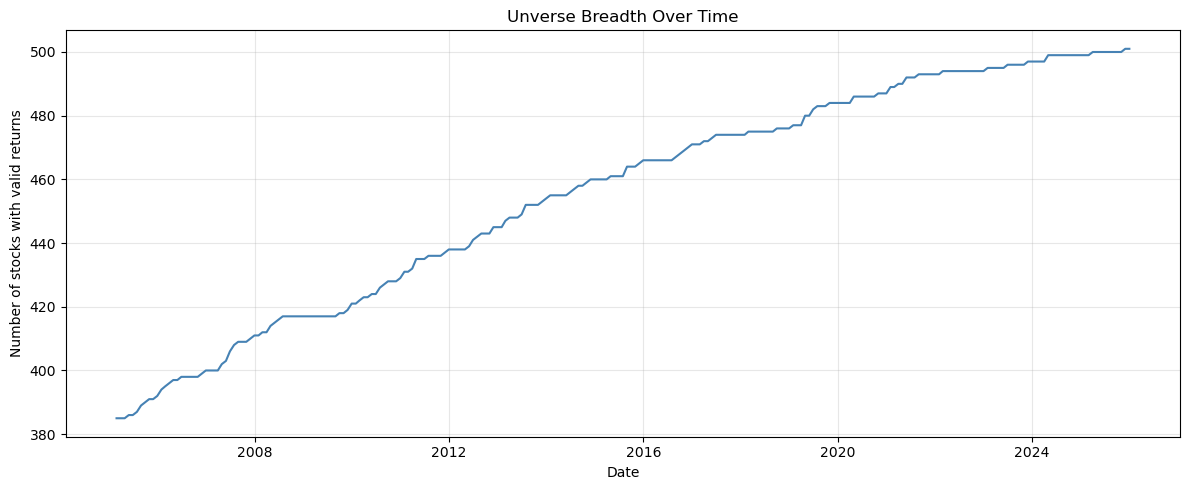

Average breadth: 455
Min breadth: 385
Max breadth: 501


In [6]:
"""
==================================
Universe breadth over time
==================================
"""
# Count non-NaN returns each month
universe_breadth = df_returns.notna().sum(axis=1)

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(universe_breadth.index, universe_breadth.values, color='steelblue')
ax.set_xlabel('Date')
ax.set_ylabel('Number of stocks with valid returns')
ax.set_title('Unverse Breadth Over Time')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/01_market_stats/universe_breadth.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average breadth: {universe_breadth.mean():.0f}")
print(f"Min breadth: {universe_breadth.min()}")
print(f"Max breadth: {universe_breadth.max()}")

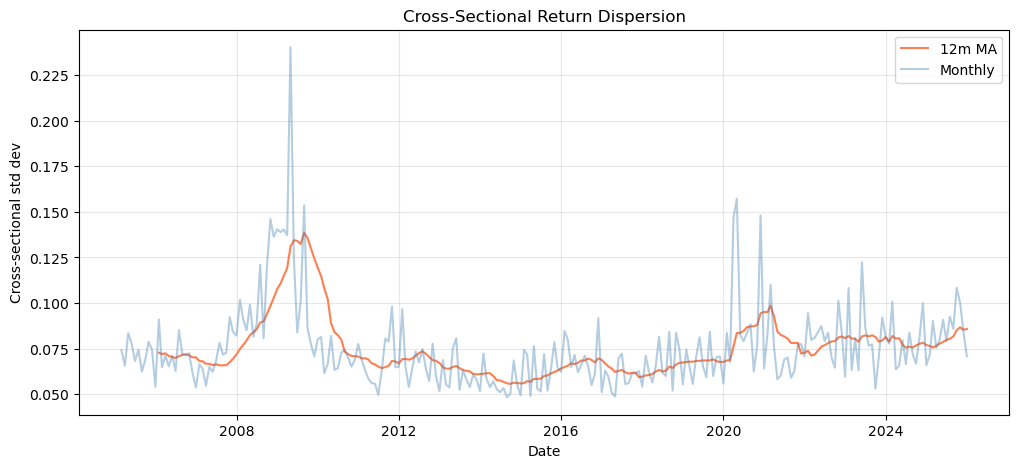

Average monthly CS dispersion: 0.0754
Annualized: 0.2610


In [7]:
"""
==================================
Cross-sectional return dispersion
==================================
"""
# Cross-sectional standard deviation each month
cs_dispersion = df_returns.std(axis=1)

fig,ax = plt.subplots(figsize=(12,5))
ax.plot(cs_dispersion.index, cs_dispersion.rolling(12).mean(), color='coral', label='12m MA') # this smooths the last 12 months
ax.plot(cs_dispersion.index, cs_dispersion, color='steelblue', alpha=0.4, label='Monthly')
ax.set_xlabel('Date')
ax.set_ylabel('Cross-sectional std dev')
ax.set_title('Cross-Sectional Return Dispersion')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout
plt.savefig('../images/01_market_stats/cs_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average monthly CS dispersion: {cs_dispersion.mean():.4f}")
print(f"Annualized: {cs_dispersion. mean() * np.sqrt(12):.4f}")

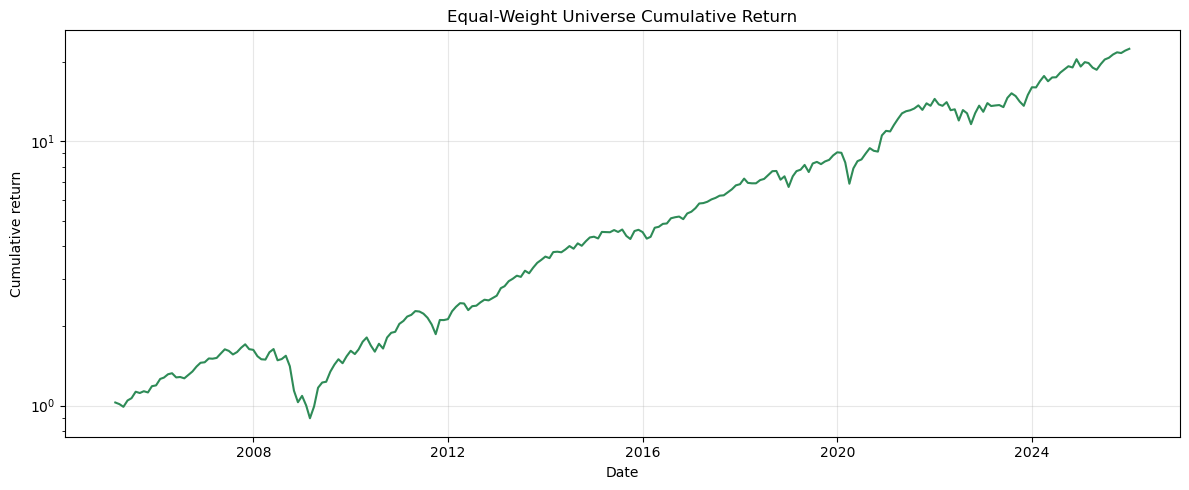

Annualized return: 0.1632
Annualized vol: 0.1659
Sharpe (rf=0): 0.984


In [8]:
"""
==================================
Equal-weight market index
==================================
"""
ew_market = df_returns.mean(axis=1)
cum_ew = (1 + ew_market).cumprod()
"""
Mathematically, .cumprod() will do the following:
W_t = prod_{s=1}^t (1 + bar{r}_s) with W_0 = 1
"""

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(cum_ew.index, cum_ew.values, color='seagreen')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative return')
ax.set_title('Equal-Weight Universe Cumulative Return')
ax.set_yscale('log')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/01_market_stats/ew_market_cumulative.png', dpi = 150, bbox_inches='tight')
plt.show()

ann_return = ew_market.mean() * 12
ann_vol = ew_market.std() * np.sqrt(12)
sharpe = ann_return / ann_vol

print(f"Annualized return: {ann_return:.4f}")
print(f"Annualized vol: {ann_vol:.4f}")
print(f"Sharpe (rf=0): {sharpe:.3f}")

## Sector Composition

Sectors are a categorical partition of the stock universe. If there are $K$ sectors, we can encode membership with a binary matrix

$$D \in \{0,1\}^{N \times K},$$

where $D_{i,k}=1$ if stock $i$ belongs to sector $k$.

This matters later because raw factors often contain sector tilts. A momentum signal might accidentally be long Technology and short Utilities, for example. If we want to study stock selection within sectors, we need to project those sector-level components out of the signal.

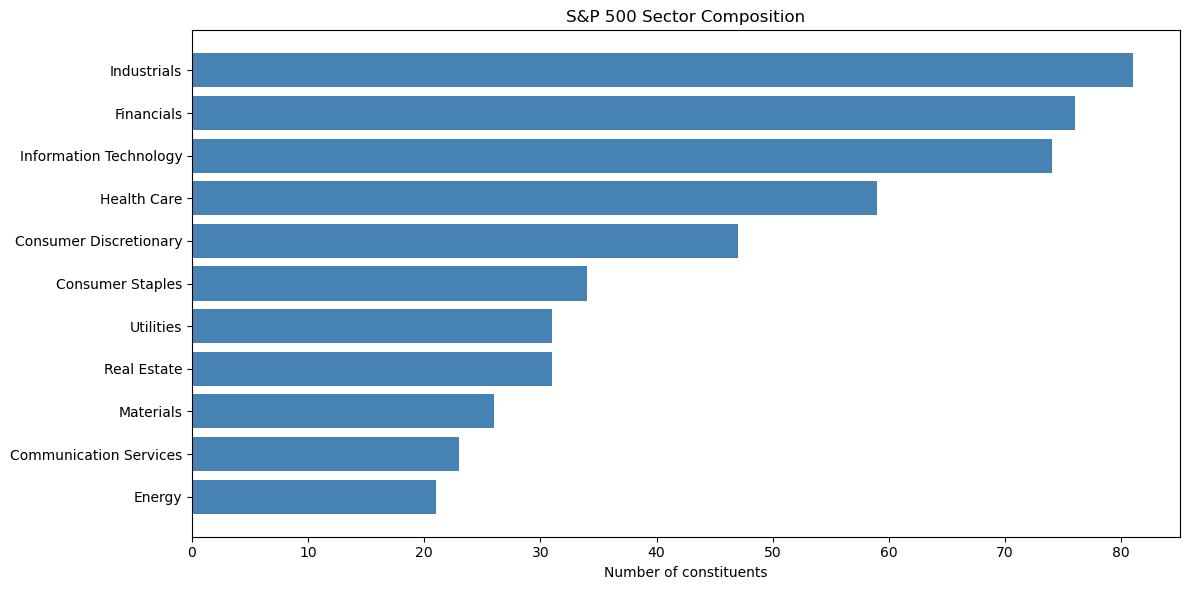

,count
sector,
Industrials,81
Financials,76
Information Technology,74
Health Care,59
Consumer Discretionary,47
Consumer Staples,34
Utilities,31
Real Estate,31
Materials,26


In [9]:
"""
==================================
Sector mapping
==================================
"""
# Use GICS sector from the constituents table
df_sector = df_constituents[['Symbol', 'GICS Sector']].copy()
df_sector.columns = ['ticker', 'sector']
df_sector = df_sector.dropna(subset=['sector'])

# Save for later
df_sector.to_csv('../data/processed/sector_mapping.csv', index=False)

sector_counts = df_sector['sector'].value_counts()

fig,ax = plt.subplots(figsize=(12,6))
ax.barh(sector_counts.index, sector_counts.values, color='steelblue')
ax.set_xlabel('Number of constituents')
ax.set_title('S&P 500 Sector Composition')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../images/01_market_stats/sector_composition.png', dpi=150, bbox_inches='tight')
plt.show()

display(sector_counts.to_frame('count'))


## Conclusion

We now have the project's core return panel $R$: a monthly, current-constituent large-cap equity panel from 2005 onward, plus sector labels and basic market diagnostics.

The important caveat is that this is a convenient public-data panel, not a survivorship-free institutional dataset. That does not make the project useless, but it does mean later claims need to be phrased carefully. The next notebook asks the first factor question: which cross-sectional score vectors have any relationship with subsequent stock returns?